# Visualization 03 Product And Crosssell

Converted from `visualizations/03_product_and_crosssell.py`.


In [1]:
# Notebook bootstrap generated from visualizations/03_product_and_crosssell.py
from pathlib import Path
import os
import sys

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == 'data_cleaning' else Path.cwd()
VISUALIZATIONS_DIR = PROJECT_ROOT / 'visualizations'
if str(VISUALIZATIONS_DIR) not in sys.path:
    sys.path.insert(0, str(VISUALIZATIONS_DIR))
os.chdir(VISUALIZATIONS_DIR)
__file__ = str(VISUALIZATIONS_DIR / '03_product_and_crosssell.py')

from IPython.display import display

def inline_save(fig, name):
    display(fig)
    try:
        import matplotlib.pyplot as plt
        plt.close(fig)
    except Exception:
        pass
    print(f"  Displayed inline: {name}")
    return None


In [2]:
"""
03_product_and_crosssell.py
Charts: cross-product LTV waterfall, product revenue mix, SKU checkout vs recurring,
        product × channel heatmap
"""
import sys
from pathlib import Path
sys.path.insert(0, str(Path(__file__).parent))

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.patches as mpatches
from style import save, TEAL, NAVY, ORANGE, RED, SLATE, GOLD, LIGHT_BG, LILAC

# Notebook override: display charts inline instead of writing PNG files.
save = inline_save



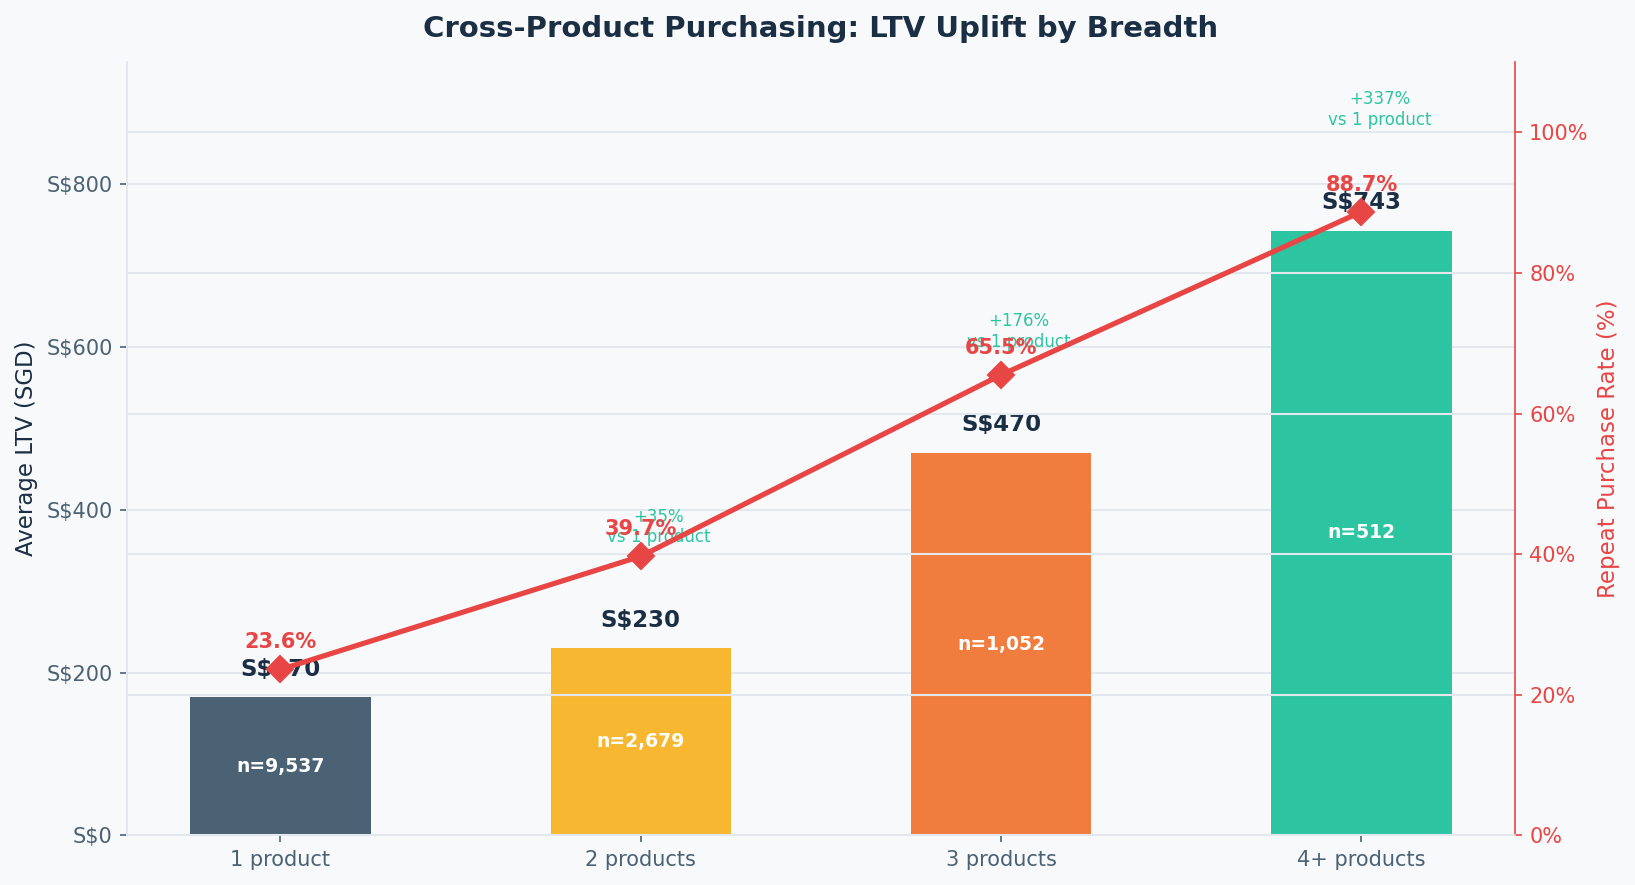

  Displayed inline: 03a_cross_product_ltv


In [3]:
# ── Chart 1: Cross-product LTV staircase ─────────────────────────────────────
labels        = ["1 product","2 products","3 products","4+ products"]
ltv           = [170, 230, 470, 743]
repeat_rate   = [23.6, 39.7, 65.5, 88.7]
n_custs       = [9537, 2679, 1052, 512]

fig, ax1 = plt.subplots(figsize=(11, 6))
colors = [SLATE, GOLD, ORANGE, TEAL]
bars = ax1.bar(labels, ltv, color=colors, width=0.5, zorder=3)
ax1.set_title("Cross-Product Purchasing: LTV Uplift by Breadth")
ax1.set_ylabel("Average LTV (SGD)", fontsize=11, color=NAVY)
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v,_: f"S${v:,.0f}"))
ax1.set_ylim(0, 950)

for bar, v, n in zip(bars, ltv, n_custs):
    ax1.text(bar.get_x()+bar.get_width()/2, bar.get_height()+20,
             f"S${v:,}", ha="center", va="bottom", fontsize=11, fontweight="bold", color=NAVY)
    ax1.text(bar.get_x()+bar.get_width()/2, bar.get_height()/2,
             f"n={n:,}", ha="center", va="center", fontsize=9, color="white", fontweight="bold")

ax2 = ax1.twinx()
ax2.plot(labels, repeat_rate, color=RED, marker="D", linewidth=2.5, markersize=9, zorder=4)
ax2.set_ylabel("Repeat Purchase Rate (%)", color=RED, fontsize=11)
ax2.set_ylim(0, 110)
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v,_: f"{v:.0f}%"))
ax2.spines["right"].set_visible(True); ax2.spines["right"].set_color(RED)
ax2.tick_params(axis="y", colors=RED)
for xi, r in zip(range(len(labels)), repeat_rate):
    ax2.text(xi, r+3, f"{r:.1f}%", ha="center", fontsize=10, color=RED, fontweight="bold")

# Uplift annotations
for i in range(1, len(ltv)):
    uplift = (ltv[i]-ltv[0])/ltv[0]*100
    ax1.annotate(f"+{uplift:.0f}%\nvs 1 product", xy=(i, ltv[i]+20),
                 xytext=(i+0.05, ltv[i]+130),
                 fontsize=8, color=TEAL, ha="center")

fig.tight_layout()
save(fig, "03a_cross_product_ltv")



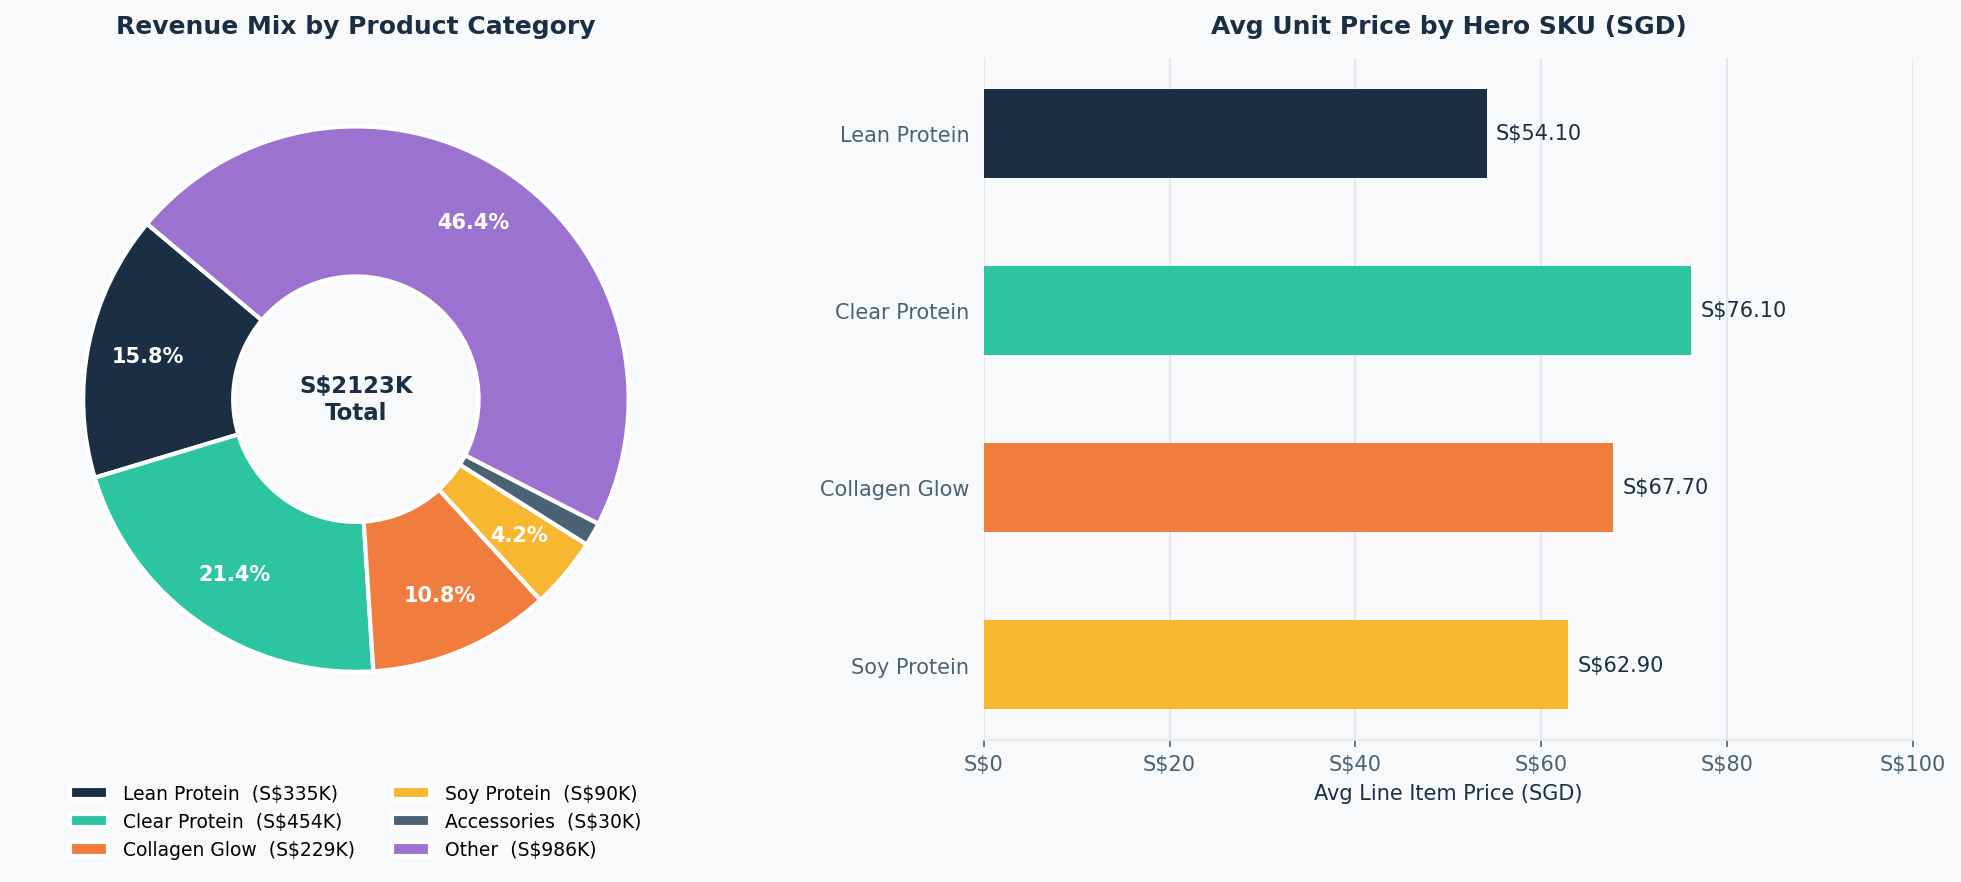

  Displayed inline: 03b_product_revenue_mix


In [4]:
# ── Chart 2: Product revenue mix (hero vs other) ──────────────────────────────
categories    = ["Lean Protein","Clear Protein","Collagen Glow","Soy Protein","Accessories","Other"]
revenues      = [334540, 453601, 229280, 89815, 29543, 985775]
unit_prices   = [54.1, 76.1, 67.7, 62.9, 13.3, 67.7]

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Donut chart
wedge_colors = [NAVY, TEAL, ORANGE, GOLD, SLATE, LILAC]
total = sum(revenues)
wedges, texts, autotexts = axes[0].pie(
    revenues, labels=None,
    colors=wedge_colors,
    autopct=lambda p: f"{p:.1f}%" if p > 4 else "",
    startangle=140,
    wedgeprops=dict(width=0.55, edgecolor="white", linewidth=2),
    pctdistance=0.78,
)
for at in autotexts:
    at.set_fontsize(10); at.set_fontweight("bold"); at.set_color("white")
legend_labels = [f"{c}  (S${r/1000:.0f}K)" for c, r in zip(categories, revenues)]
axes[0].legend(wedges, legend_labels, loc="lower center", bbox_to_anchor=(0.5, -0.2),
               ncol=2, fontsize=9)
axes[0].set_title("Revenue Mix by Product Category", fontsize=12, fontweight="bold")
axes[0].text(0, 0, f"S${total/1000:.0f}K\nTotal", ha="center", va="center",
             fontsize=11, fontweight="bold", color=NAVY)

# Avg unit price comparison
hero_cats  = ["Lean Protein","Clear Protein","Collagen Glow","Soy Protein"]
hero_prices= [54.1, 76.1, 67.7, 62.9]
hero_colors= [NAVY, TEAL, ORANGE, GOLD]
axes[1].barh(hero_cats[::-1], hero_prices[::-1], color=hero_colors[::-1], height=0.5, zorder=3)
axes[1].set_title("Avg Unit Price by Hero SKU (SGD)", fontsize=12, fontweight="bold")
axes[1].set_xlabel("Avg Line Item Price (SGD)", fontsize=10)
axes[1].xaxis.set_major_formatter(mticker.FuncFormatter(lambda v,_: f"S${v:.0f}"))
for i, v in enumerate(hero_prices[::-1]):
    axes[1].text(v+1, i, f"S${v:.2f}", va="center", fontsize=10, color=NAVY)
axes[1].grid(axis="x"); axes[1].grid(axis="y", visible=False)
axes[1].spines["left"].set_visible(False); axes[1].tick_params(left=False)
axes[1].set_xlim(0, 100)

fig.tight_layout()
save(fig, "03b_product_revenue_mix")



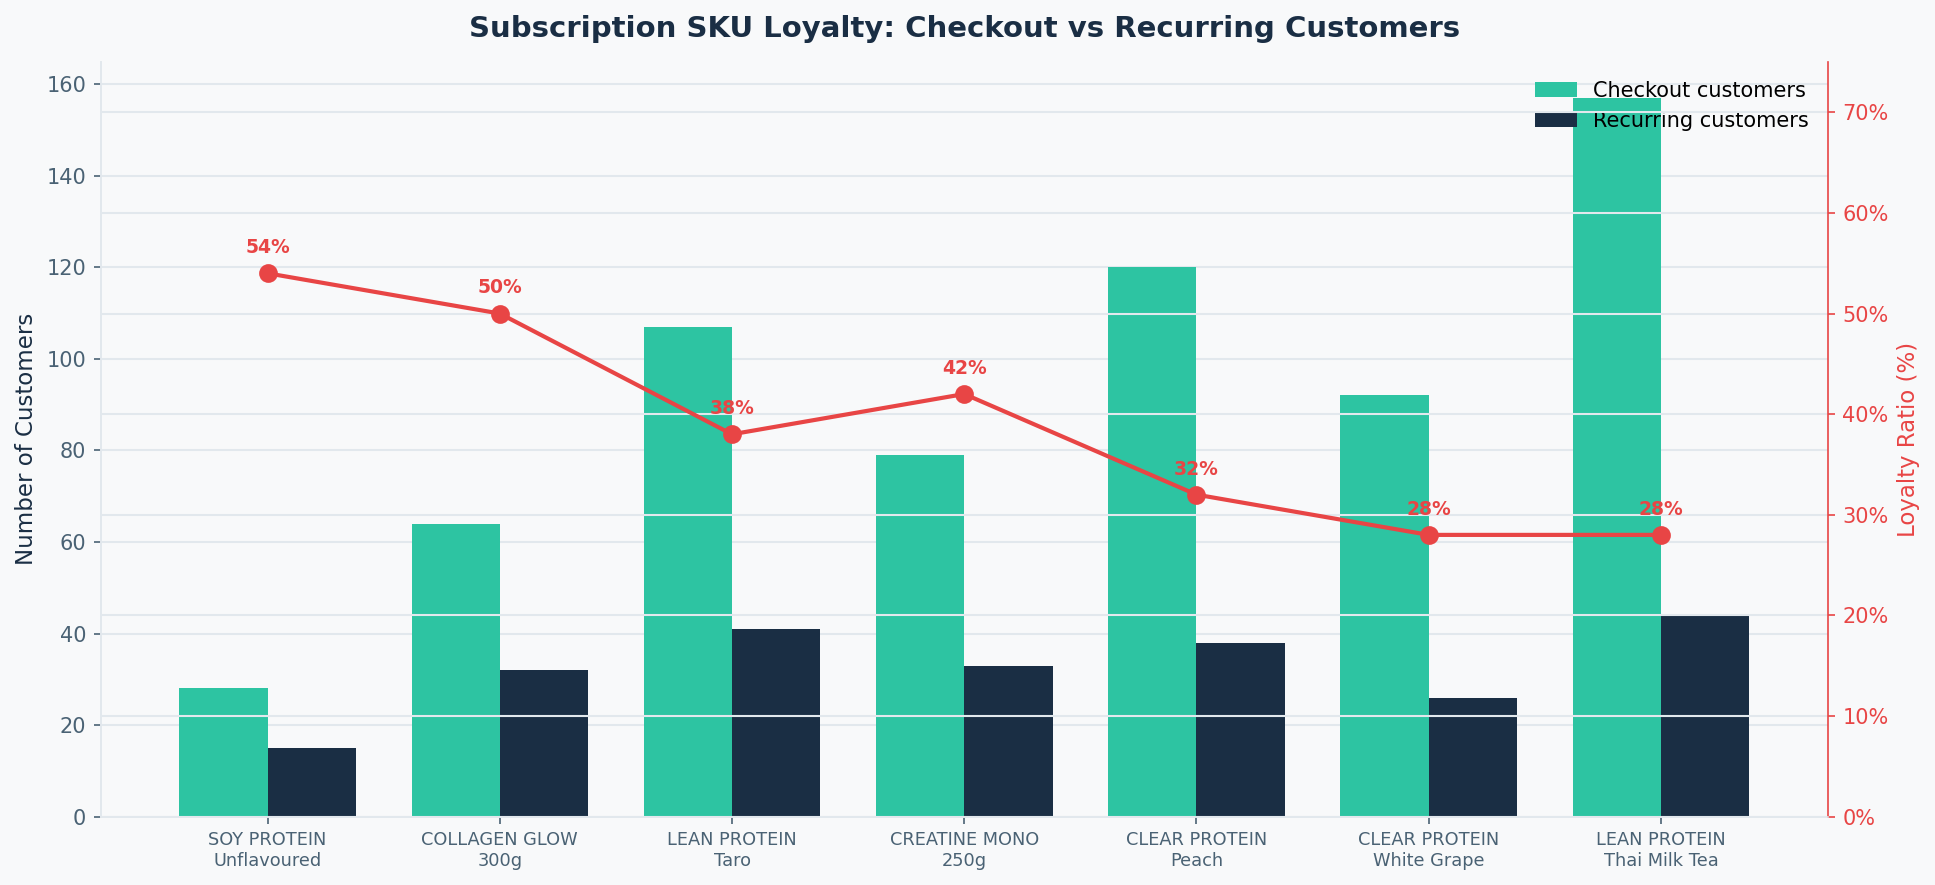

  Displayed inline: 03c_sku_loyalty


In [5]:
# ── Chart 3: SKU loyalty — checkout vs recurring ─────────────────────────────
skus          = ["SOY PROTEIN\nUnflavoured","COLLAGEN GLOW\n300g","LEAN PROTEIN\nTaro","CREATINE MONO\n250g","CLEAR PROTEIN\nPeach","CLEAR PROTEIN\nWhite Grape","LEAN PROTEIN\nThai Milk Tea"]
checkout_n    = [28, 64, 107, 79, 120, 92, 157]
recurring_n   = [15, 32,  41, 33,  38, 26,  44]
loyalty_ratio = [0.54, 0.50, 0.38, 0.42, 0.32, 0.28, 0.28]

x = np.arange(len(skus)); w = 0.38
fig, ax1 = plt.subplots(figsize=(13, 6))
b1 = ax1.bar(x-w/2, checkout_n,  width=w, color=TEAL,  label="Checkout customers",  zorder=3)
b2 = ax1.bar(x+w/2, recurring_n, width=w, color=NAVY,  label="Recurring customers", zorder=3)
ax1.set_xticks(x); ax1.set_xticklabels(skus, fontsize=8.5)
ax1.set_title("Subscription SKU Loyalty: Checkout vs Recurring Customers")
ax1.set_ylabel("Number of Customers", fontsize=11)
ax1.legend(loc="upper right")

ax2 = ax1.twinx()
ax2.plot(x, [r*100 for r in loyalty_ratio], color=RED, marker="o", linewidth=2, markersize=8, zorder=4)
ax2.set_ylabel("Loyalty Ratio (%)", color=RED, fontsize=11)
ax2.set_ylim(0, 75)
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v,_: f"{v:.0f}%"))
ax2.spines["right"].set_visible(True); ax2.spines["right"].set_color(RED)
ax2.tick_params(axis="y", colors=RED)
for xi, r in zip(x, loyalty_ratio):
    ax2.text(xi, r*100+2, f"{r*100:.0f}%", ha="center", fontsize=9, color=RED, fontweight="bold")

fig.tight_layout()
save(fig, "03c_sku_loyalty")



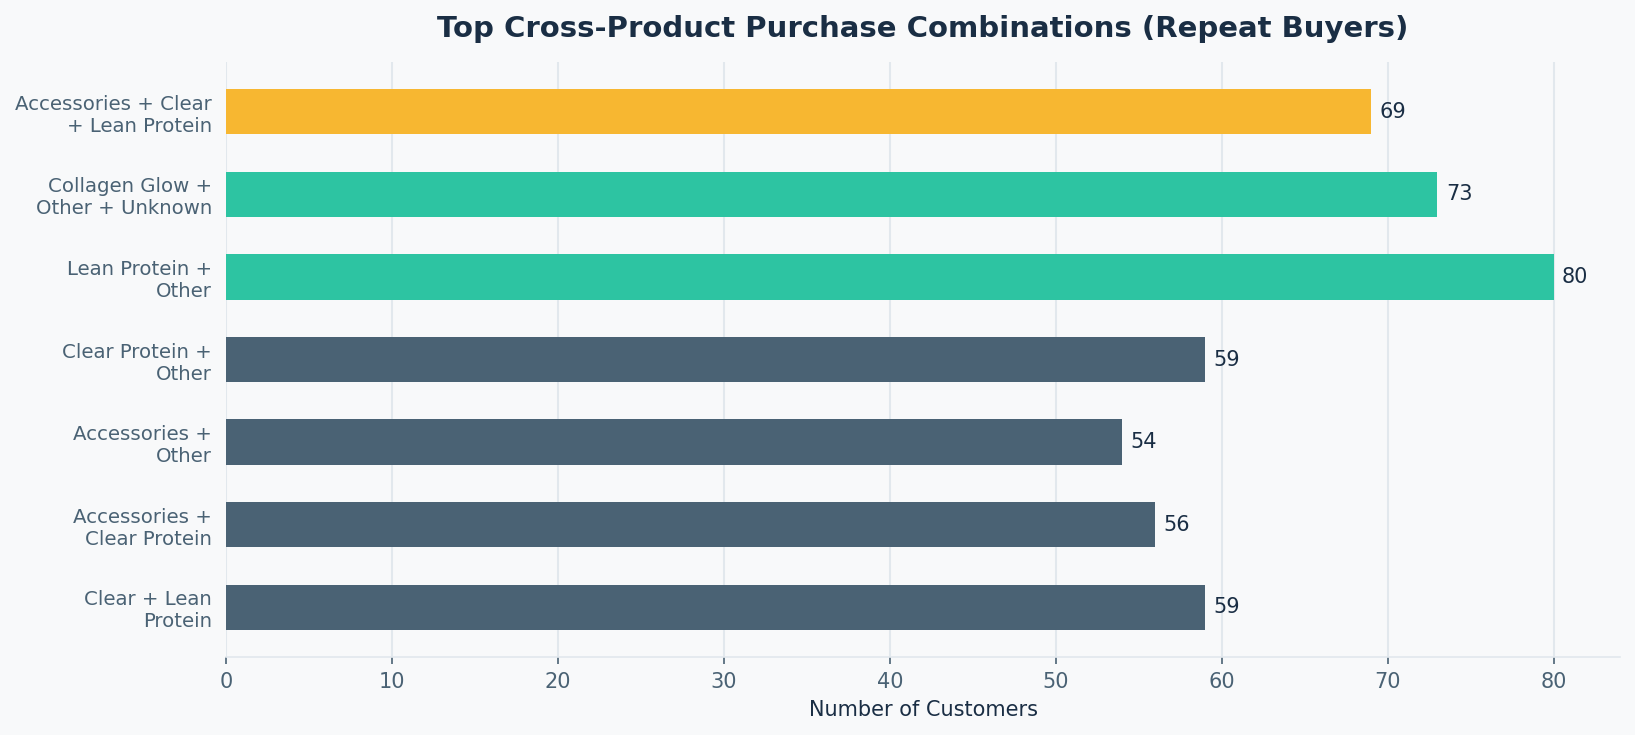

  Displayed inline: 03d_top_product_combos
Done – 03_product_and_crosssell


In [6]:
# ── Chart 4: Top product combos (repeat buyers) ───────────────────────────────
combos = [
    "Clear + Lean\nProtein",
    "Accessories +\nClear Protein",
    "Accessories +\nOther",
    "Clear Protein +\nOther",
    "Lean Protein +\nOther",
    "Collagen Glow +\nOther + Unknown",
    "Accessories + Clear\n+ Lean Protein",
]
combo_counts = [59, 56, 54, 59, 80, 73, 69]

fig, ax = plt.subplots(figsize=(11, 5))
y = np.arange(len(combos))
bar_colors = [TEAL if c > 70 else GOLD if c > 60 else SLATE for c in combo_counts]
ax.barh(y, combo_counts, color=bar_colors, height=0.55, zorder=3)
ax.set_yticks(y); ax.set_yticklabels(combos, fontsize=9.5)
ax.set_title("Top Cross-Product Purchase Combinations (Repeat Buyers)")
ax.set_xlabel("Number of Customers", fontsize=10)
for i, v in enumerate(combo_counts):
    ax.text(v+0.5, i, str(v), va="center", fontsize=10, color=NAVY)
ax.grid(axis="x"); ax.grid(axis="y", visible=False)
ax.spines["left"].set_visible(False); ax.tick_params(left=False)
fig.tight_layout()
save(fig, "03d_top_product_combos")

print("Done – 03_product_and_crosssell")
